# Chapter 5 — Pretraining on Unlabeled Data (simplified)

A self-contained pretraining run using the from-scratch `GPTModel` from `gpt_architecture.py`, trained on a single short story with a shortened **256-token** context window.

In [2]:
from importlib.metadata import version

import torch
import tiktoken

from gpt_architecture import GPTModel, generate_text_simple

for p in ["torch", "tiktoken", "matplotlib"]:
    print(f"{p} version: {version(p)}")

torch version: 2.12.1
tiktoken version: 0.13.0
matplotlib version: 3.10.9


## 5.1 Evaluating generative text models

### 5.1.1 Using GPT to generate text

We reuse the GPT-2 (124M) architecture but shorten the context length to 256 tokens to keep training light enough to run on a laptop. Restoring it to 1024 requires no code changes.

In [3]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 256,  # Shortened context length (orig: 1024)
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of transformer blocks
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False,      # Bias for the Q/K/V projections
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()  # Disable dropout during inference

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_q): Linear(in_features=768, out_features=768, bias=False)
        (W_k): Linear(in_features=768, out_features=768, bias=False)
        (W_v): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_q): Linear(in_features=768, out_feat

Two convenience functions convert between text and token-ID tensors; they are used throughout the notebook. The untrained model produces gibberish — that's expected.

In [4]:
tokenizer = tiktoken.get_encoding("gpt2")


def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    return torch.tensor(encoded).unsqueeze(0)  # add batch dimension


def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)  # remove batch dimension
    return tokenizer.decode(flat.tolist())


start_context = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"],
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


### 5.1.2 Calculating the text generation loss

The training signal is the cross-entropy between the model's predicted next-token distribution and the actual next token. PyTorch's `cross_entropy` applies softmax and the log internally, so we just flatten the batch dimension. Perplexity (`exp(loss)`) is often more interpretable — roughly the effective vocabulary the model is unsure about at each step.

In [5]:
inputs = torch.tensor([[16833, 3626, 6100],   # "every effort moves"
                       [40,    1107,  588]])   # "I really like"

targets = torch.tensor([[3626, 6100,  345],    # " effort moves you"
                        [1107,  588, 11311]])   # " really like chocolate"

with torch.no_grad():
    logits = model(inputs)

# cross_entropy expects (N, vocab) logits and (N,) targets, so flatten the batch.
loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), targets.flatten())
perplexity = torch.exp(loss)
print("Loss:", loss)
print("Perplexity:", perplexity)

Loss: tensor(10.7940)
Perplexity: tensor(48725.8203)


### 5.1.3 Calculating the training and validation set losses

We train on a single public-domain short story (*The Verdict*). It's tiny (~5k tokens) — enough to watch the model learn (and quickly overfit) in a few minutes.

In [6]:
import os
import urllib.request

file_path = "the-verdict.txt"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/"
    "ch02/01_main-chapter-code/the-verdict.txt"
)

if not os.path.exists(file_path):
    urllib.request.urlretrieve(url, file_path)

with open(file_path, "r", encoding="utf-8") as f:
    text_data = f.read()

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


The data loader (from chapter 2) tokenizes the text once, then slides a window of `max_length` over it. Targets are the inputs shifted by one position, since we train the model to predict the next token.

In [11]:
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    """Tokenizes the full text once, then slices it into overlapping (input, target) windows."""

    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Target is the input shifted by one token.
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1:i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128,
                         shuffle=True, drop_last=True, num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
    )

In [12]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0,
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0,
)

# Sanity check: each split needs enough tokens to fill at least one context window.
if total_tokens * train_ratio < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Lower context_length or raise train_ratio.")
if total_tokens * (1 - train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Lower context_length or lower train_ratio.")

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 9
Val batches: 1


Two helpers compute the cross-entropy loss for a single batch and (averaged) over a number of batches in a loader.

In [13]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    return torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.0
    if len(data_loader) == 0:
        return float("nan")
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        # Cap at the number of batches actually available.
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        total_loss += loss.item()
    return total_loss / num_batches

Pick the best available device (CUDA, Apple MPS, or CPU) and measure the loss before any training, as a baseline.

In [14]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using {device} device.")

model.to(device)

torch.manual_seed(123)  # reproducible shuffling in the data loader
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using mps device.
Training loss: 10.987583054436577
Validation loss: 10.98110580444336


## 5.2 Training an LLM

A minimal training loop: standard forward / backward / optimizer step, with periodic evaluation and a generated text sample after each epoch.

In [ ]:
def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward() # The optimizer uses the gradient to compute an update, then applies that update to the weights.
            optimizer.step() 
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                      )

        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

In [16]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

Now run training. The training loss drops quickly while the validation loss plateaus — with such a tiny dataset the model soon memorizes (overfits) the story.

In [23]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004, weight_decay=0.1
)
num_epochs = 100
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.817, Val loss 9.924
Ep 1 (Step 000005): Train loss 8.066, Val loss 8.332
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.619, Val loss 7.042
Ep 2 (Step 000015): Train loss 6.046, Val loss 6.596
Every effort moves you, and,, and, and,,,,, and, and,,,,,,,,,,, and,, the,, the, and,, and,,, the, and,,,,,,
Ep 3 (Step 000020): Train loss 5.524, Val loss 6.508
Ep 3 (Step 000025): Train loss 5.369, Val loss 6.378
Every effort moves you, and to the of the of the picture. Gis.                                     
Ep 4 (Step 000030): Train loss 4.830, Val loss 6.263
Ep 4 (Step 000035): Train loss 4.586, Val loss 6.285
Every effort moves you of the "I the picture.                    "I"I the picture"I had the picture"I the picture and I had been the picture of
Ep 5 (Step 000040): Train loss 3.879, Val loss 6.130
Every effort moves you know he had been his pictures, and I felt it's by his last word.          

Plot training vs. validation loss against epochs, with tokens seen on the top axis.

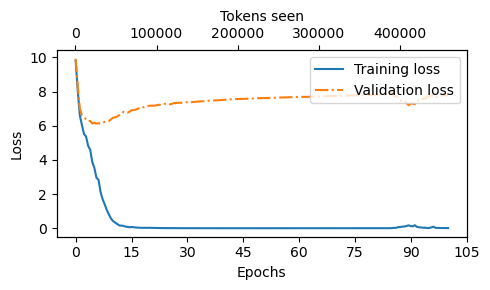

In [24]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## 5.3 Decoding strategies to control randomness

Greedy decoding (`argmax`) is deterministic and repetitive. Temperature scaling and top-k sampling add controlled diversity.

### 5.3.1 Temperature scaling

Dividing logits by a temperature before softmax sharpens (`T < 1`, more confident) or flattens (`T > 1`, more diverse) the distribution.

In [20]:
vocab = {
    "closer": 0, "every": 1, "effort": 2, "forward": 3, "inches": 4,
    "moves": 5, "pizza": 6, "toward": 7, "you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}

# Hypothetical next-token logits for "every effort moves you".
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)


def softmax_with_temperature(logits, temperature):
    return torch.softmax(logits / temperature, dim=0)


def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for _ in range(1_000)]
    counts = torch.bincount(torch.tensor(sample), minlength=len(probas))
    for i, freq in enumerate(counts):
        print(f"{freq:4d} x {inverse_vocab[i]}")


for T in [1.0, 0.1, 5.0]:
    print(f"\nTemperature = {T}")
    print_sampled_tokens(softmax_with_temperature(next_token_logits, T))


Temperature = 1.0
  73 x closer
   0 x every
   0 x effort
 582 x forward
   2 x inches
   0 x moves
   0 x pizza
 343 x toward
   0 x you

Temperature = 0.1
   0 x closer
   0 x every
   0 x effort
 985 x forward
   0 x inches
   0 x moves
   0 x pizza
  15 x toward
   0 x you

Temperature = 5.0
 165 x closer
  75 x every
  42 x effort
 239 x forward
  71 x inches
  46 x moves
  32 x pizza
 227 x toward
 103 x you


### 5.3.2 Top-k sampling

Restrict sampling to the `k` highest-logit tokens by masking the rest to `-inf` before softmax. This avoids the rare nonsensical picks that high temperatures can produce.

In [21]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)

# Mask everything below the k-th largest logit.
new_logits = torch.where(
    next_token_logits < top_logits[-1],
    torch.tensor(float("-inf")),
    next_token_logits,
)
topk_probas = torch.softmax(new_logits, dim=0)
print("Top positions:", top_pos.tolist())
print("Top-k probabilities:", topk_probas)

Top positions: [3, 7, 0]
Top-k probabilities: tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### 5.3.3 Modifying the text generation function

Combine temperature and top-k into a single `generate` function — a drop-in upgrade of `generate_text_simple`. With `temperature=0.0` it falls back to greedy argmax.

In [22]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]  # focus on the last time step

        # Optional top-k filtering.
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float("-inf")).to(logits.device),
                logits,
            )

        # Temperature scaling + sampling, or greedy argmax when temperature == 0.
        if temperature > 0.0:
            logits = logits / temperature
            logits = logits - logits.max(dim=-1, keepdim=True).values  # mps-stable softmax
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if idx_next == eos_id:  # stop early on end-of-sequence token
            break
        idx = torch.cat((idx, idx_next), dim=1)
    return idx


torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4,
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you just because as down and pushed one of the deep, and down She wanted
